به نام خدا

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:

batch_size = 256
learning_rate = 1e-3
num_epochs = 20
latent_dim = 32

In [3]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, transform=transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.1MB/s]


In [4]:
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
def add_noise(images, noise_factor=0.2):
    noisy = images + noise_factor * torch.randn_like(images)
    noisy = torch.clamp(noisy, -1., 1.)
    return noisy

In [6]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Tanh()  #
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [7]:

model = Autoencoder(latent_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
noise_factor = 0.2

In [10]:
train_losses = []
for epoch in range(num_epochs):
    running_loss = 0.0
    for data in train_loader:
        img, _ = data
        img = img.view(img.size(0), -1).to(device)

        noisy_img = add_noise(img, noise_factor)

        outputs = model(noisy_img)
        loss = criterion(outputs, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')



Epoch [1/20], Loss: 0.1542
Epoch [2/20], Loss: 0.0779
Epoch [3/20], Loss: 0.0680
Epoch [4/20], Loss: 0.0621
Epoch [5/20], Loss: 0.0578
Epoch [6/20], Loss: 0.0548
Epoch [7/20], Loss: 0.0524
Epoch [8/20], Loss: 0.0507
Epoch [9/20], Loss: 0.0492
Epoch [10/20], Loss: 0.0480
Epoch [11/20], Loss: 0.0469
Epoch [12/20], Loss: 0.0460
Epoch [13/20], Loss: 0.0452
Epoch [14/20], Loss: 0.0446
Epoch [15/20], Loss: 0.0440
Epoch [16/20], Loss: 0.0435
Epoch [17/20], Loss: 0.0430
Epoch [18/20], Loss: 0.0426
Epoch [19/20], Loss: 0.0422
Epoch [20/20], Loss: 0.0419


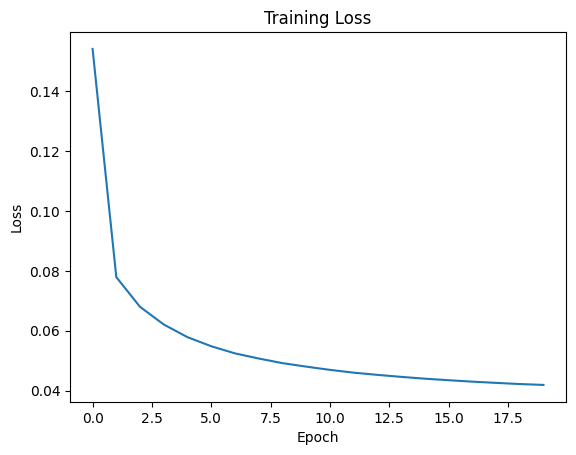

In [11]:
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

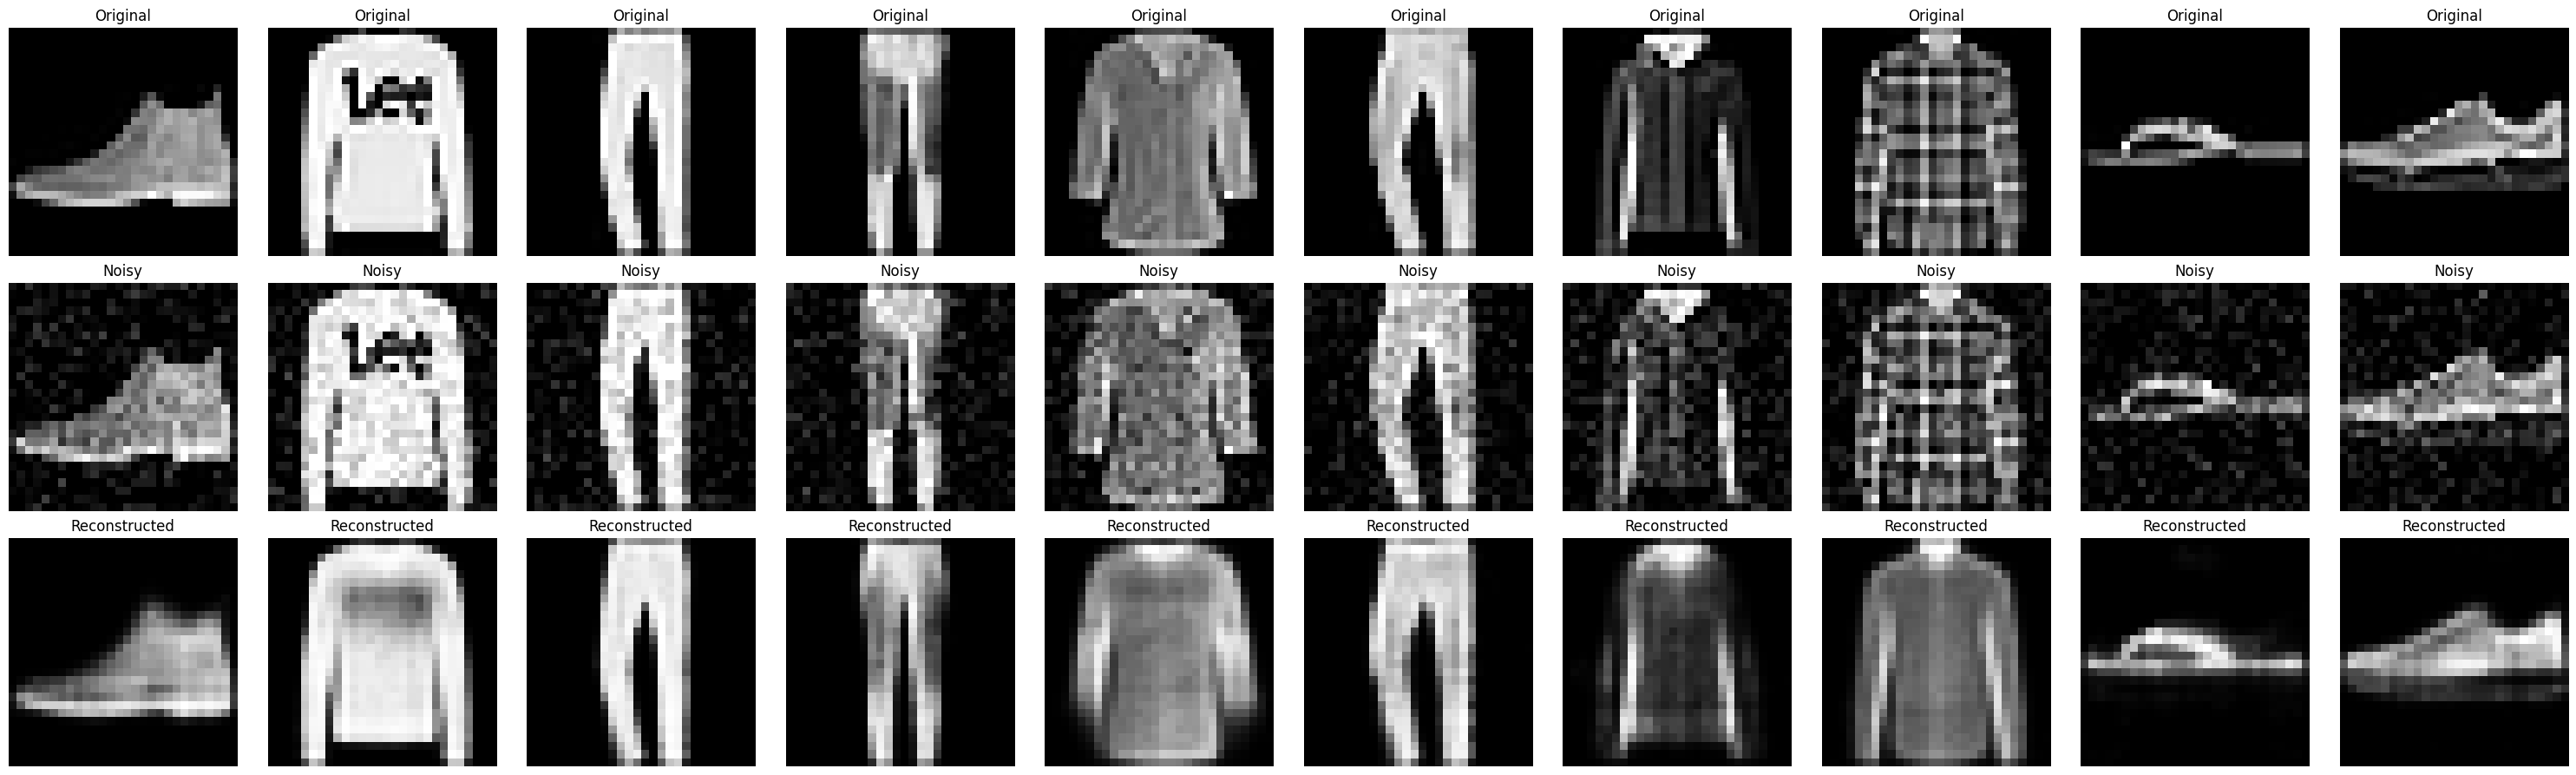

In [14]:
def test_denoising_autoencoder():
    model.eval()
    with torch.no_grad():
        for data in test_loader:
            img, _ = data
            img = img.view(img.size(0), -1).to(device)

            noisy_img = add_noise(img, noise_factor)
            outputs = model(noisy_img)

            img = img.cpu().numpy()
            noisy_img = noisy_img.cpu().numpy()
            outputs = outputs.cpu().numpy()

            fig, axes = plt.subplots(nrows=3, ncols=10, figsize=(30, 9))
            for i in range(10):
                axes[0, i].imshow(img[i].reshape(28, 28), cmap='gray')
                axes[0, i].set_title('Original')
                axes[0, i].axis('off')

                axes[1, i].imshow(noisy_img[i].reshape(28, 28), cmap='gray')
                axes[1, i].set_title('Noisy')
                axes[1, i].axis('off')

                axes[2, i].imshow(outputs[i].reshape(28, 28), cmap='gray')
                axes[2, i].set_title('Reconstructed')
                axes[2, i].axis('off')

            plt.tight_layout()
            plt.show()
            break

test_denoising_autoencoder()

In [15]:

class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [16]:
model = Autoencoder(latent_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [17]:
train_losses = []
for epoch in range(num_epochs):
    running_loss = 0.0
    for data in train_loader:
        img, _ = data
        img = img.view(img.size(0), -1).to(device)

        noisy_img = add_noise(img, noise_factor)

        outputs = model(noisy_img)
        loss = criterion(outputs, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')



Epoch [1/20], Loss: 0.1838
Epoch [2/20], Loss: 0.0880
Epoch [3/20], Loss: 0.0764
Epoch [4/20], Loss: 0.0700
Epoch [5/20], Loss: 0.0661
Epoch [6/20], Loss: 0.0631
Epoch [7/20], Loss: 0.0607
Epoch [8/20], Loss: 0.0590
Epoch [9/20], Loss: 0.0576
Epoch [10/20], Loss: 0.0563
Epoch [11/20], Loss: 0.0551
Epoch [12/20], Loss: 0.0541
Epoch [13/20], Loss: 0.0531
Epoch [14/20], Loss: 0.0521
Epoch [15/20], Loss: 0.0514
Epoch [16/20], Loss: 0.0503
Epoch [17/20], Loss: 0.0496
Epoch [18/20], Loss: 0.0487
Epoch [19/20], Loss: 0.0482
Epoch [20/20], Loss: 0.0476


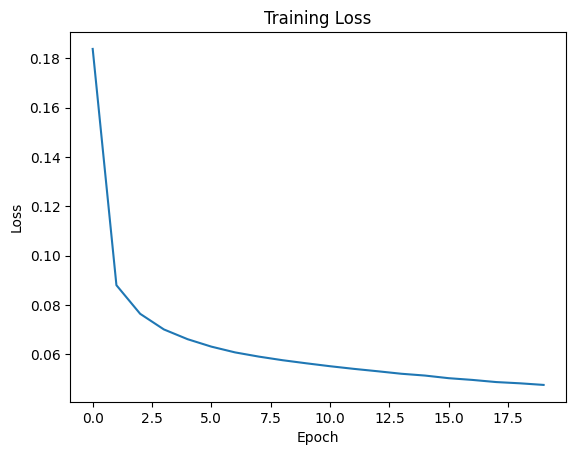

In [18]:
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

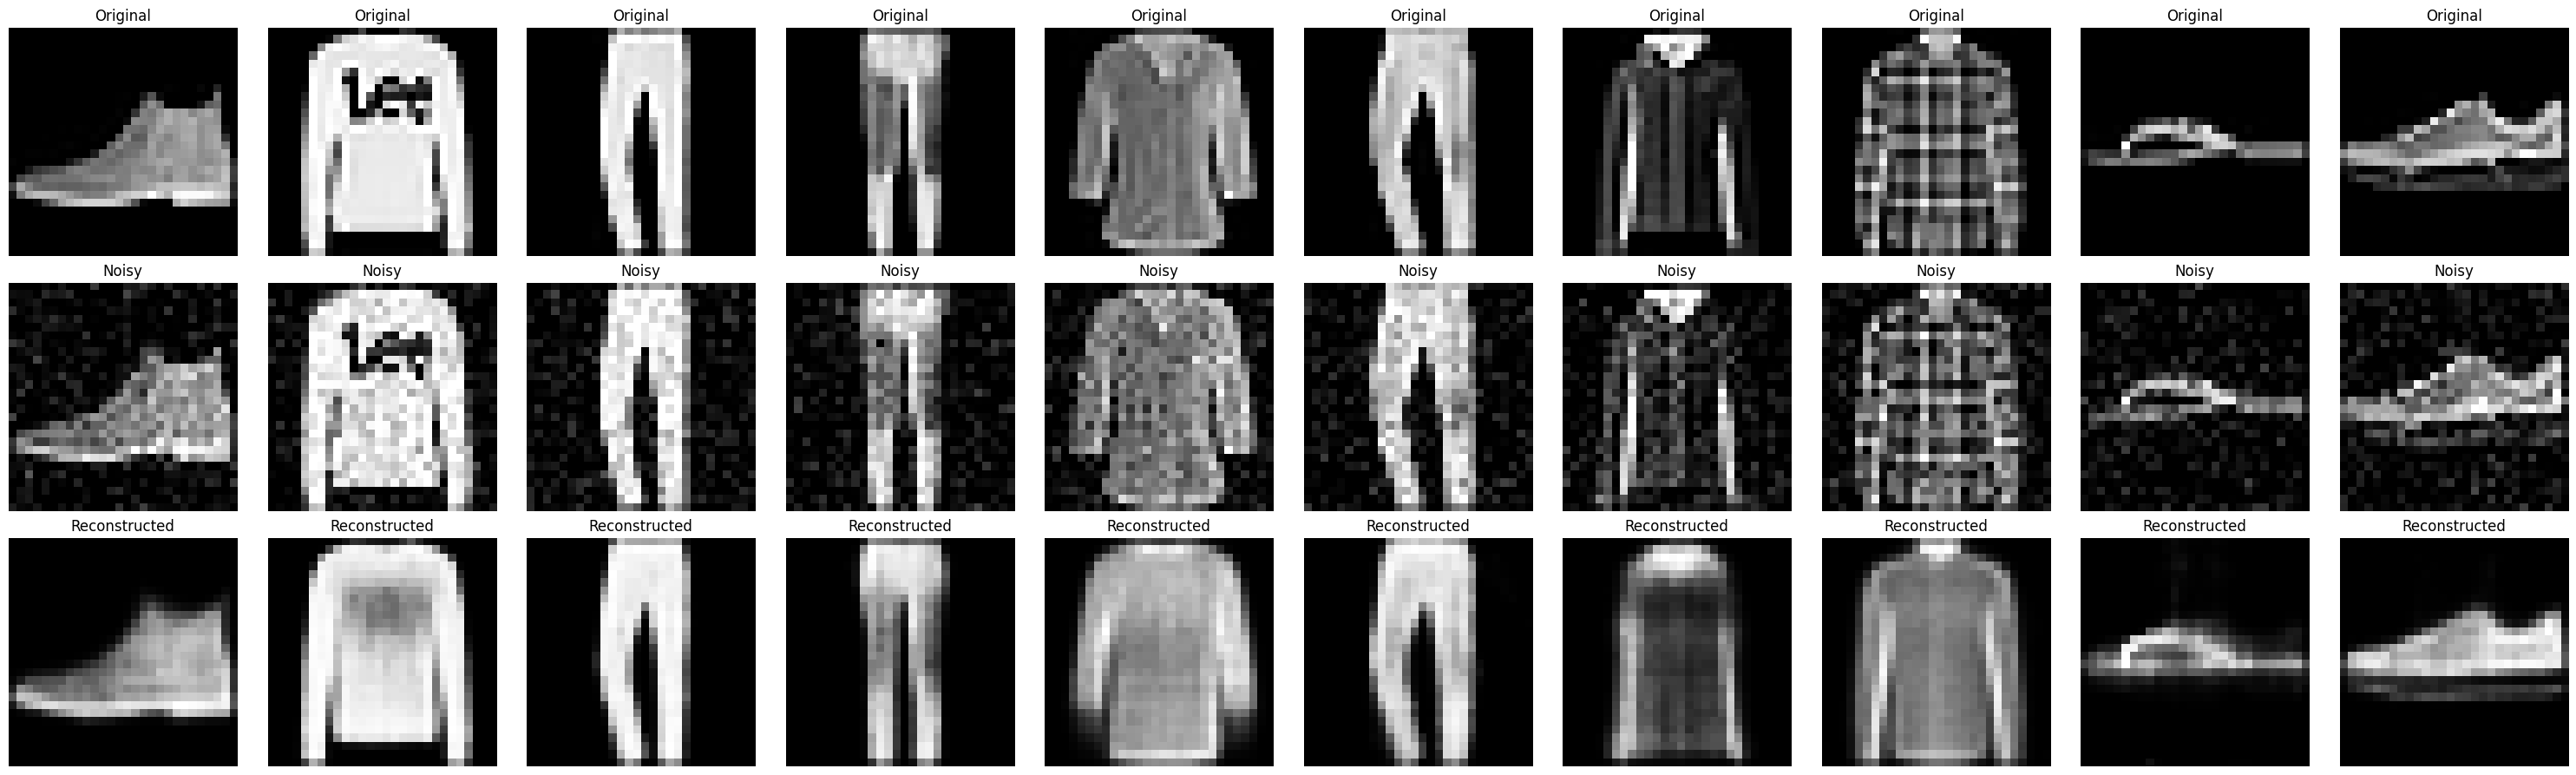

In [19]:
test_denoising_autoencoder()

In [20]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28*28),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [21]:
model = Autoencoder(latent_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [22]:
train_losses = []
for epoch in range(num_epochs):
    running_loss = 0.0
    for data in train_loader:
        img, _ = data
        img = img.view(img.size(0), -1).to(device)
        noisy_img = add_noise(img, noise_factor)

        outputs = model(noisy_img)
        loss = criterion(outputs, img)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')



Epoch [1/20], Loss: 0.1346
Epoch [2/20], Loss: 0.0703
Epoch [3/20], Loss: 0.0598
Epoch [4/20], Loss: 0.0533
Epoch [5/20], Loss: 0.0494
Epoch [6/20], Loss: 0.0467
Epoch [7/20], Loss: 0.0448
Epoch [8/20], Loss: 0.0433
Epoch [9/20], Loss: 0.0420
Epoch [10/20], Loss: 0.0411
Epoch [11/20], Loss: 0.0401
Epoch [12/20], Loss: 0.0395
Epoch [13/20], Loss: 0.0389
Epoch [14/20], Loss: 0.0384
Epoch [15/20], Loss: 0.0379
Epoch [16/20], Loss: 0.0374
Epoch [17/20], Loss: 0.0372
Epoch [18/20], Loss: 0.0368
Epoch [19/20], Loss: 0.0366
Epoch [20/20], Loss: 0.0362


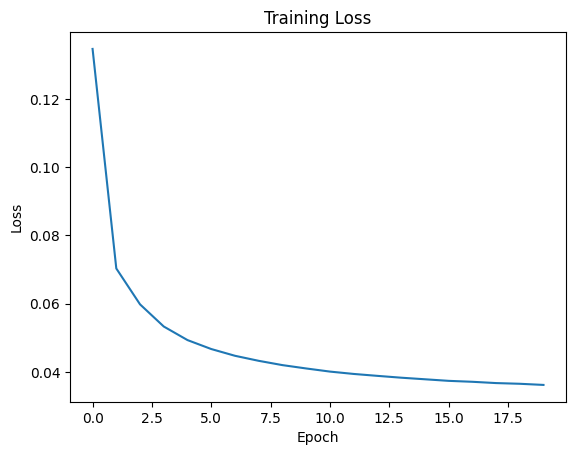

In [23]:

plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

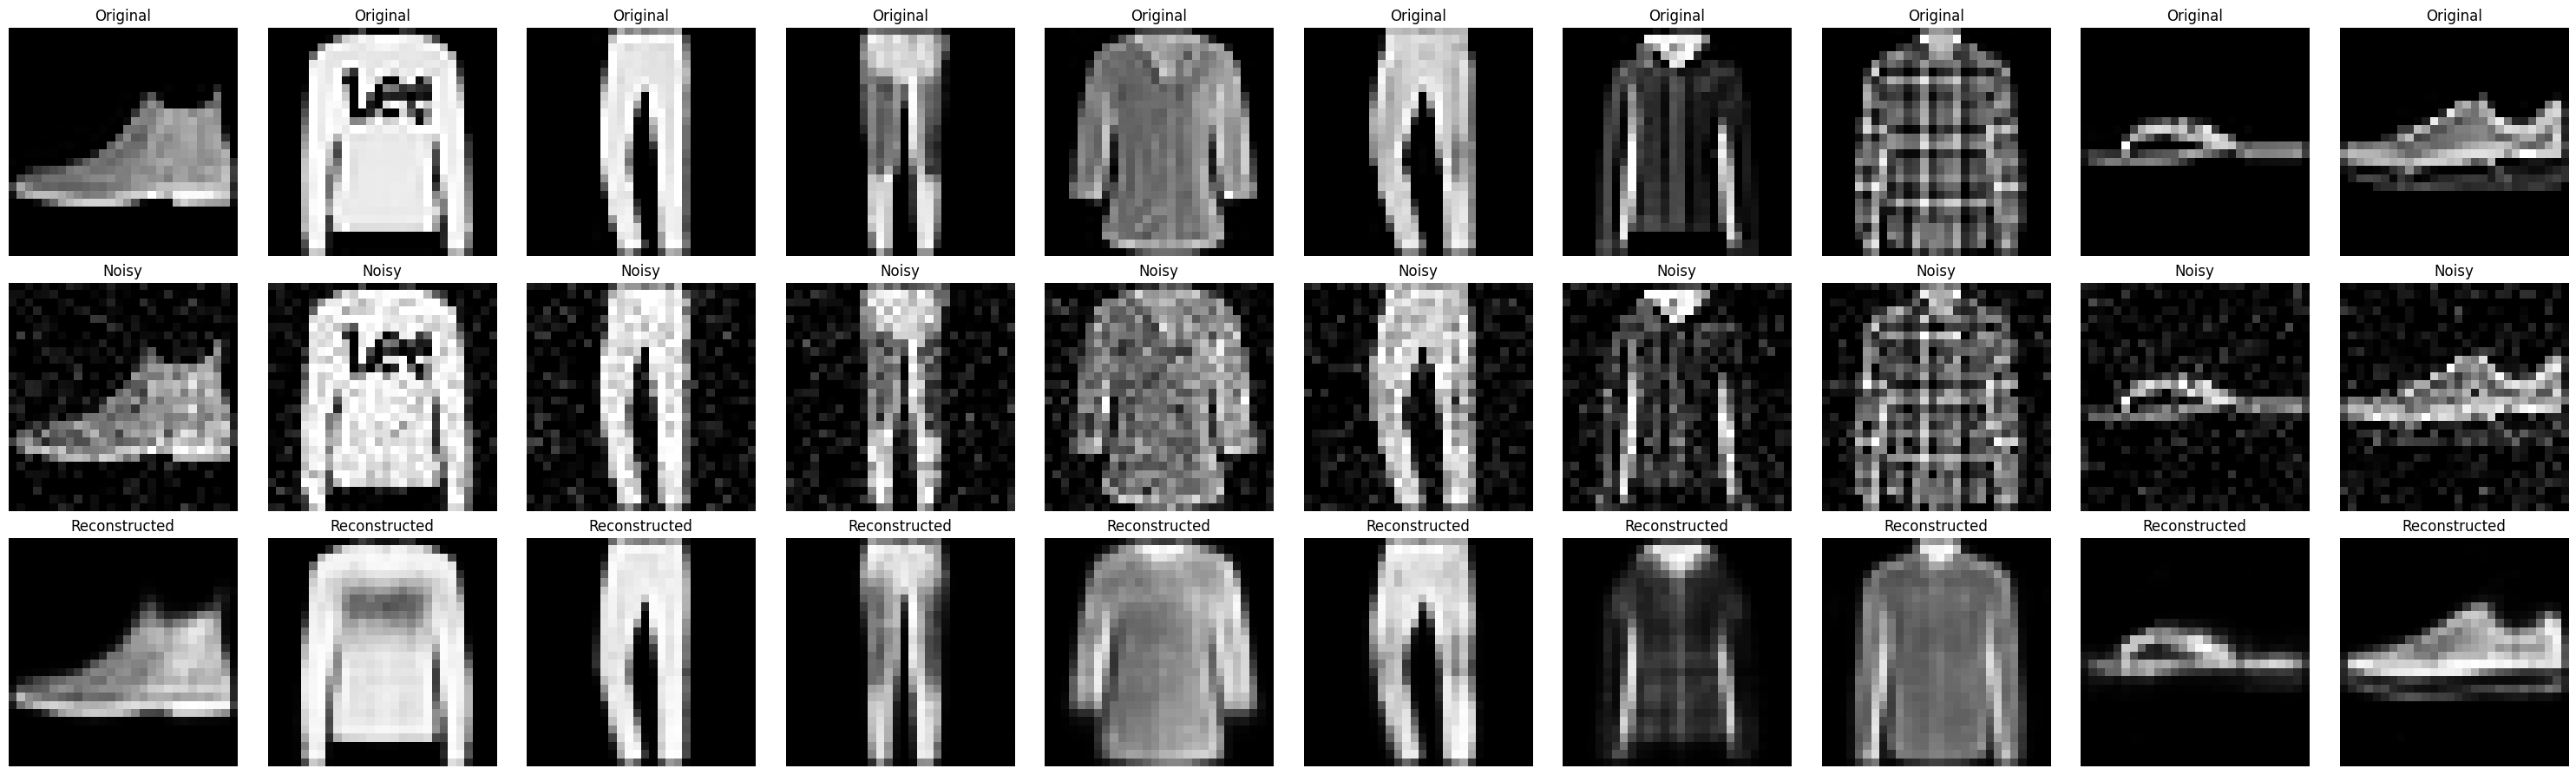

In [24]:
test_denoising_autoencoder()

In [25]:
model = Autoencoder(latent_dim).to(device)
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [26]:
train_losses = []
for epoch in range(num_epochs):
    running_loss = 0.0
    for data in train_loader:
        img, _ = data
        img = img.view(img.size(0), -1).to(device)

        noisy_img = add_noise(img, noise_factor)

        outputs = model(noisy_img)
        loss = criterion(outputs, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

Epoch [1/20], Loss: 0.2252
Epoch [2/20], Loss: 0.1505
Epoch [3/20], Loss: 0.1324
Epoch [4/20], Loss: 0.1236
Epoch [5/20], Loss: 0.1178
Epoch [6/20], Loss: 0.1139
Epoch [7/20], Loss: 0.1108
Epoch [8/20], Loss: 0.1084
Epoch [9/20], Loss: 0.1065
Epoch [10/20], Loss: 0.1050
Epoch [11/20], Loss: 0.1036
Epoch [12/20], Loss: 0.1024
Epoch [13/20], Loss: 0.1013
Epoch [14/20], Loss: 0.1002
Epoch [15/20], Loss: 0.0995
Epoch [16/20], Loss: 0.0990
Epoch [17/20], Loss: 0.0981
Epoch [18/20], Loss: 0.0973
Epoch [19/20], Loss: 0.0968
Epoch [20/20], Loss: 0.0963


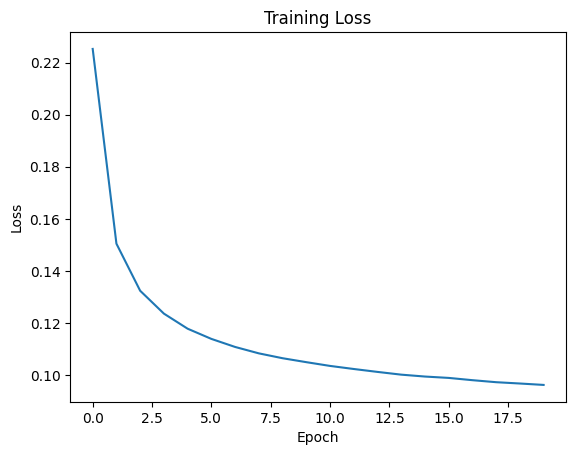

In [ ]:
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

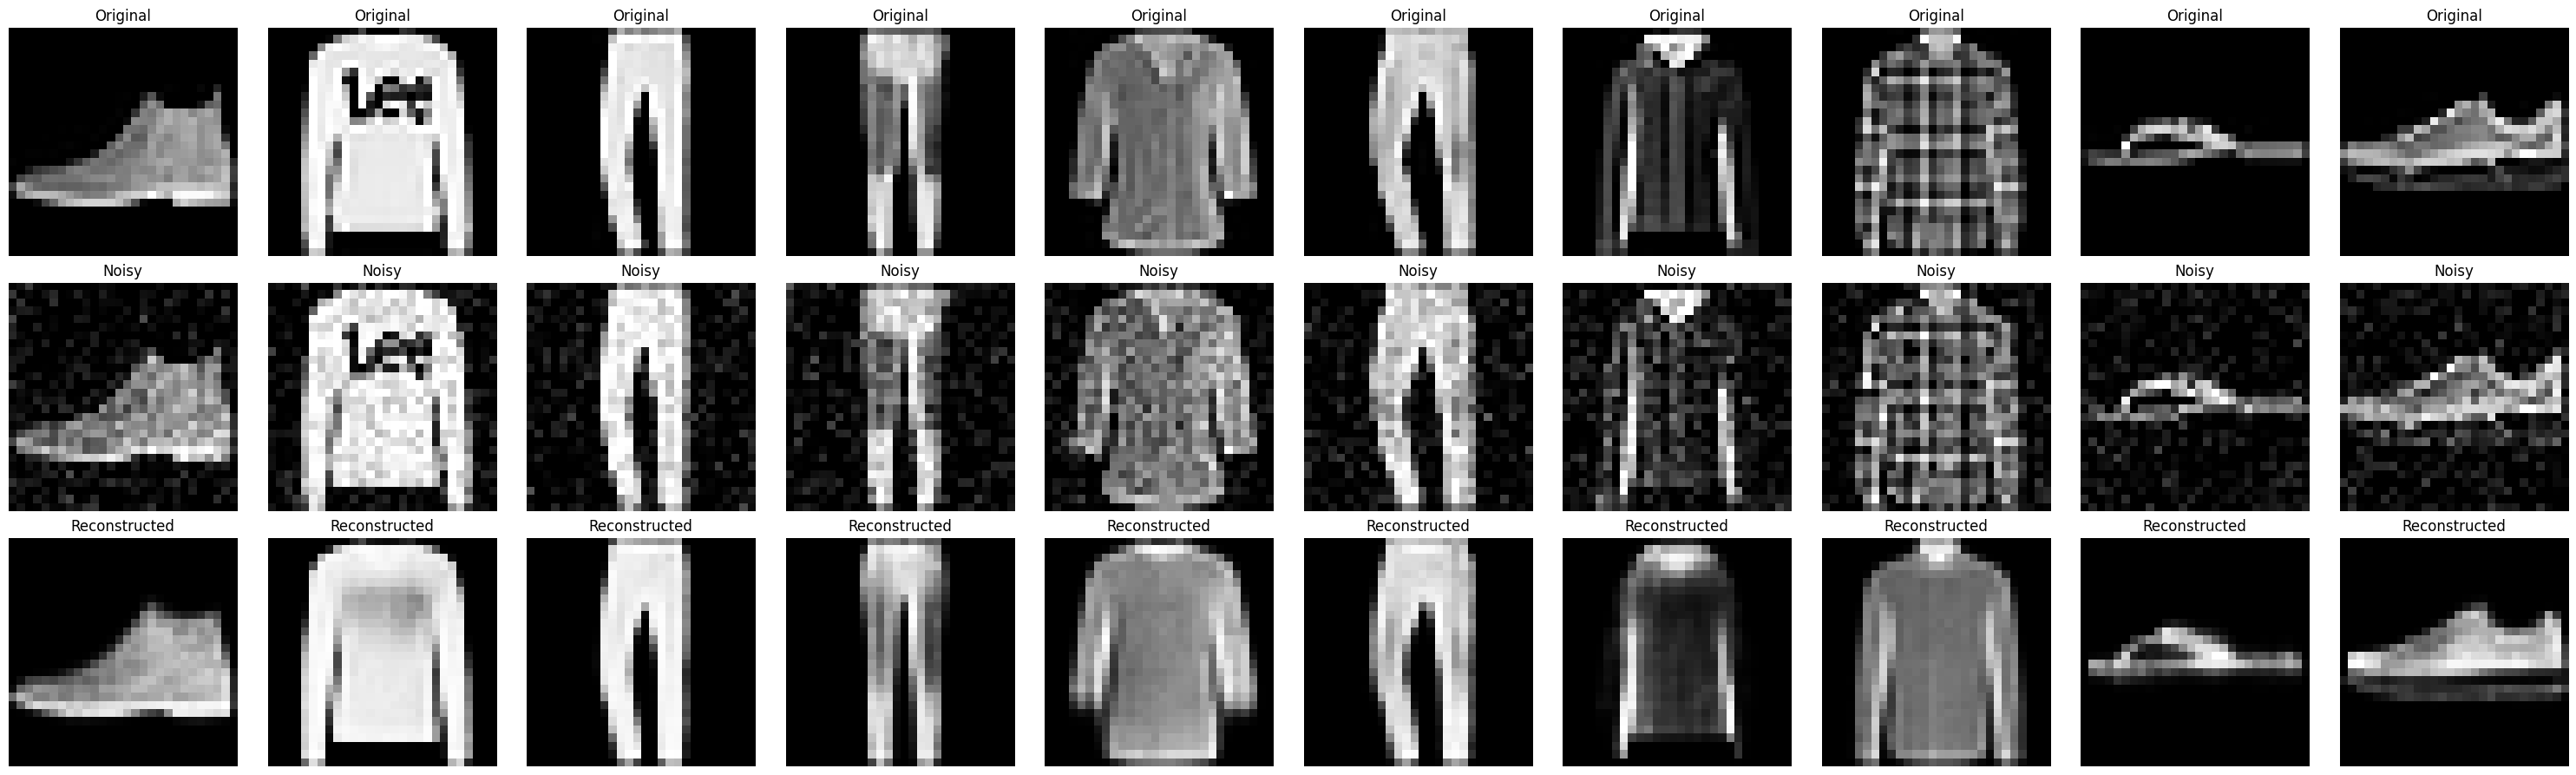

In [28]:
test_denoising_autoencoder()

In [29]:
0.1+0.2

0.30000000000000004